# Supply Chain Audit: Diagnosing a 57.29% Late-Delivery Rate & an 18.71% Loss-Making Order Rate
> **Key Results: Late deliveries are a scheduling-promise problem in most modes but a genuine execution problem in Second Class — and 18.71% of orders lose money for structural pricing reasons, not any single fixable cause.**

---

### Project Overview
This audit investigates two separate questions across 180,519 transactions: why **18.71%** of orders lose money, and why the dataset's reported **54.8% late-delivery rate** doesn't hold up once cancelled orders and shipping-mode differences are accounted for. Both findings point away from a single fixable cause and toward structural, catalog-wide and schedule-wide issues.

### Top Metrics Discovered:
* **Loss-Making Orders:** **18.71%** of orders (33,784 of 180,519) lose money. Category, product, discount rate, order quantity, and delivery status were all tested and ruled out individually — the loss is a structural pricing issue spread evenly across the catalog, not a fixable operational cause.
* **Corrected Late-Delivery Rate:** The true late rate among orders that actually shipped is **57.29%**, not the reported 54.8% — the original figure was diluted by including cancelled orders (7,754 rows) in the denominator. Among orders that do run late, the average delay is **1.62 days**.
* **Two Different Shipping Problems:** First Class and Same Day show high "late" rates mainly because their scheduled windows (1 day / 0 days) are unrealistically tight — a **promise problem**. Second Class, scheduled for 2 days but running 2.5 days over on 79.8% of orders, is a genuine **execution problem** and the mode that most deserves an operational review.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_column', None)


In [2]:
# single source-of-truth loading + cleaning cell — run this whenever df needs a fresh start
# dataset expected in the same folder as this notebook (relative path -> works on any machine/OS)
DATA_PATH = 'DataCoSupplyChainDataset.csv'

import os
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Couldn't find '{DATA_PATH}'. Download the dataset (DataCo Smart Supply Chain, Kaggle) "
        "and place the CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH, encoding='latin-1')
# drop unneeded / sensitive columns
df = df.drop(columns=['Product Description', 'Order Zipcode', 'Customer Password', 'Customer Email'])

# handle missing values
df['Customer Lname'] = df['Customer Lname'].fillna('unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(-1)

# convert date columns — this MUST happen before anything using .dt
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# remove duplicates
df = df.drop_duplicates()

# confirm everything is correct
print(df.info())
print(df[date_cols].dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [3]:
                                              #EDA and KPIS
# total sales 
total_sales = df['Sales'].sum()
print('total sales = $',round(total_sales,2))


total sales = $ 36784735.01


In [4]:
# total profit & profit margin
total_profit = df['Order Profit Per Order'].sum()
profit_margin = (total_profit/total_sales)*100 
print("profit =  $",round(total_profit,2))
print("profitability = ","%",round(profit_margin,2))

profit =  $ 3966902.97
profitability =  % 10.78


In [ ]:
# negative profit orders 
negative_profit_orders = (df['Order Profit Per Order'] < 0).mean() * 100
negative_profit_count = (df['Order Profit Per Order'] < 0).sum()

print("negative profit orders = ",round(negative_profit_orders,2),"%")
print("negative profit count = ",negative_profit_count)

# single source-of-truth filters — reused in every loss-vs-profit comparison below
lossing_orders = df[df['Order Profit Per Order'] < 0]
profitable_orders = df[df['Order Profit Per Order'] > 0]

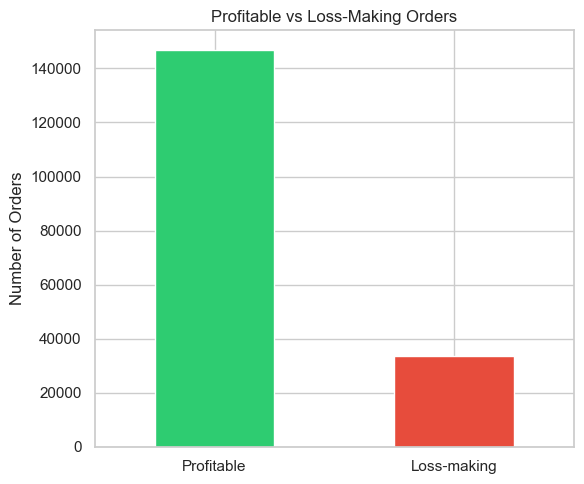

In [6]:
# visualize profitable vs loss-making orders
profit_status_counts = (df['Order Profit Per Order'] < 0).value_counts()
profit_status_counts.index = ['Profitable', 'Loss-making']

profit_status_counts.plot(kind='bar', figsize=(6, 5), color=['#2ecc71', '#e74c3c'])
plt.title('Profitable vs Loss-Making Orders')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# breakdown of negative profit orders by product category
category_loss_breakdown = lossing_orders.groupby('Category Name').agg(
    total_loss = ('Order Profit Per Order', 'sum'),
    loss_count = ('Order Profit Per Order', 'count'),
    average_loss = ('Order Profit Per Order', 'mean')
).sort_values(by='loss_count', ascending=False) 

print(category_loss_breakdown)

In [8]:
# net profit (total, not just loss) by product category
category_net_profit = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False)
print(category_net_profit)


Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27178.099597
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13223.399926
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.83989

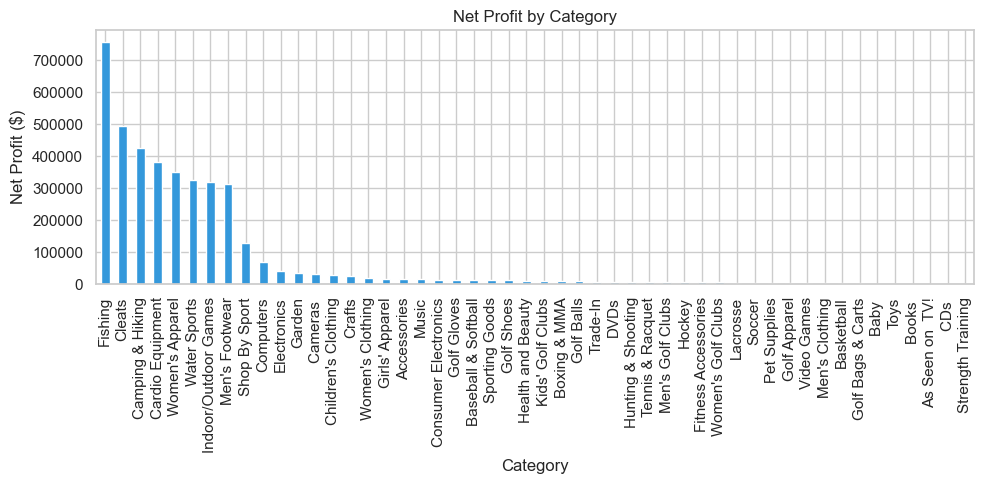

In [9]:
# visualize net profit per category (shows Fishing/Cleats/Camping are still net positive)
category_net_profit.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), color='#3498db')
plt.title('Net Profit by Category')
plt.ylabel('Net Profit ($)')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:**
Losses aren't coming from one category — almost every category has some. So this probably isn't a "one bad category" problem.

In [ ]:
# compare discount rate : lossing orders vs profitable orders
avg_discount_lossing = lossing_orders['Order Item Discount Rate'].mean()
avg_discount_profitable = profitable_orders['Order Item Discount Rate'].mean()

print("Average discount rate for loss-making orders",round(avg_discount_lossing,4))
print("Average discount rate for profitable orders:",round(avg_discount_profitable,4))

**Insight:**
Loss-making orders discount 10.22% on average, profitable ones discount 10.16%. Basically no difference. Discounts aren't causing the losses.

In [ ]:
# compare quantity  : lossing orders vs profitable orders
avg_quantity_lossing = lossing_orders['Order Item Quantity'].mean()
avg_quantity_profitable = profitable_orders['Order Item Quantity'].mean()

print("Average quantity for loss-making orders:", round(avg_quantity_lossing, 2))
print("Average quantity for profitable orders:", round(avg_quantity_profitable, 2))

**Insight:**
Average quantity per order is 2.13 either way — loss or profit. Quantity doesn't explain it.

In [ ]:
# breakdown of negative profit orders by product name
negative_product_loss_breakdown = lossing_orders.groupby('Product Name').agg(
    loss_count = ('Order Profit Per Order', 'count'),
    total_loss = ('Order Profit Per Order', 'sum'),
    average_loss = ('Order Profit Per Order', 'mean')
).sort_values(by='loss_count',ascending=False)

print(negative_product_loss_breakdown)


In [13]:
# how many times this product appears in total (all orders, not just losses)
PRODUCT_name = 'Field & Stream Sportsman 16 Gun Fire Safe'

total_appearances = df[df['Product Name'] == PRODUCT_name].shape[0]

loss_appearances = 3209

loss_percentage = (loss_appearances / total_appearances) * 100

print("total times this product was ordered:", total_appearances)
print("times it lost money:", loss_appearances)
print("loss percentage:", round(loss_percentage, 2), "%")

total times this product was ordered: 17325
times it lost money: 3209
loss percentage: 18.52 %


**Insight:**
The product with the most losses (Field & Stream Sportsman Safe) just gets ordered a ton — its loss rate (18.52%) is basically the dataset average. Even the worst products only reach 21-24%, not far above the 18.71% baseline. So no single product is the culprit.

In [14]:
# average profit and loss-rate: late deliveries vs on-time deliveries
late_deliveries = df[df['Late_delivery_risk'] == 1]
ontime_deliveries = df[df['Late_delivery_risk'] == 0]

avg_profit_late = late_deliveries['Order Profit Per Order'].mean()
avg_profit_ontime = ontime_deliveries['Order Profit Per Order'].mean()

loss_rate_late = (late_deliveries['Order Profit Per Order'] < 0).mean() * 100
loss_rate_ontime = (ontime_deliveries['Order Profit Per Order'] < 0).mean() * 100

print("avg profit - late orders:", round(avg_profit_late, 2))
print("avg profit - on-time orders:", round(avg_profit_ontime, 2))
print("loss % - late orders:", round(loss_rate_late, 2), "%")
print("loss % - on-time orders:", round(loss_rate_ontime, 2), "%")

avg profit - late orders: 21.62
avg profit - on-time orders: 22.4
loss % - late orders: 18.74 %
loss % - on-time orders: 18.68 %


In [ ]:
# loss rate (%) per product, filtering out low-volume products first

total_by_product = df.groupby('Product Name').size()
loss_by_product = lossing_orders.groupby('Product Name').size()

loss_rate = (loss_by_product / total_by_product) * 100

# only keep products with a decent sample size (at least 50 orders total)
loss_rate_filtered = loss_rate[total_by_product >= 50]

loss_rate_sorted = loss_rate_filtered.sort_values(ascending=False)

print(loss_rate_sorted.head(15))

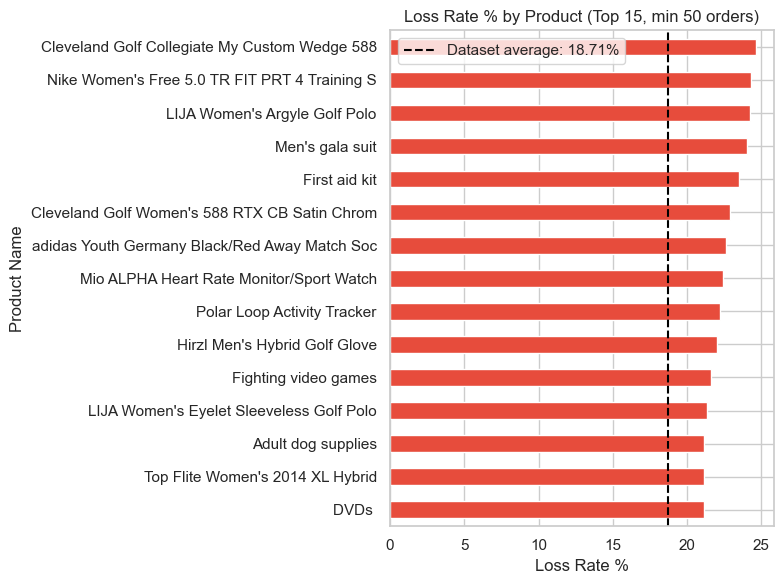

In [16]:
# visualize loss rate % for top 15 products (volume-filtered)
loss_rate_sorted.head(15).plot(kind='barh', figsize=(8, 6), color='#e74c3c')
plt.title('Loss Rate % by Product (Top 15, min 50 orders)')
plt.xlabel('Loss Rate %')
plt.axvline(18.71, color='black', linestyle='--', label='Dataset average: 18.71%')
plt.legend()
plt.gca().invert_yaxis()  # highest loss rate on top
plt.tight_layout()
plt.show()

**Insight:**
18.71% of orders (33,784 out of 180,519) lose money. I checked category, product, discount rate, quantity, and late delivery status one by one — none of them explain it, the loss rate stays around 18-19% no matter how I slice it. So this doesn't look like one broken thing I can fix — it looks more like the pricing itself just runs on thin margins, and a steady chunk of orders end up negative fairly randomly across the whole catalog.

In [17]:
# calculate shipping gap between real and scheduled delivery

df['shipping gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

avg_gap = df['shipping gap'].mean()
late_pct = (df['shipping gap'] > 0).mean() * 100

print("average shipping gap (days):", round(avg_gap, 2))
print("percentage of orders shipped late:", round(late_pct, 2), "%")

average shipping gap (days): 0.57
percentage of orders shipped late: 57.28 %


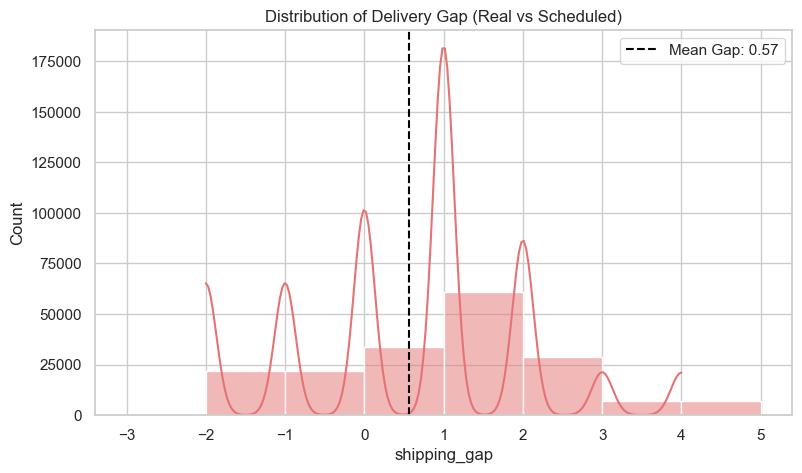

In [18]:
# visualize the distribution of shipping_gap to see what the 0.57-day average is hiding
plt.figure(figsize=(9, 5))
sns.histplot(df['shipping gap'], bins=range(-3, 6), kde=True, color='#e57373')
plt.axvline(avg_gap, color='black', linestyle='--', label=f'Mean Gap: {avg_gap:.2f}')
plt.title('Distribution of Delivery Gap (Real vs Scheduled)')
plt.xlabel('shipping_gap')
plt.ylabel('Count')
plt.legend()
plt.show()

**Insight:**
The 0.57-day average looks small, but it's hiding a lot. Once I plotted it, the gaps aren't bunched around 0 — they're spread across clear peaks from -2 to +4 days. That's why the late rate ends up so high even though the average looks tiny. Next: take cancelled orders out and look at the late ones on their own.

In [19]:
# check unique values in Delivery Status to understand definitions
df['Delivery Status'].unique()
print(df['Delivery Status'].value_counts())

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [20]:
# check shipping_gap for cancelled orders specifically
cancelled = df[df['Delivery Status'] == 'Shipping canceled']
print("avg shipping_gap for cancelled orders:", round(cancelled['shipping gap'].mean(), 2))
print("% of cancelled orders where shipping_gap > 0:", round((cancelled['shipping gap'] > 0).mean() * 100, 2), "%")

# check if shipping_gap matches Delivery Status for each category
gap_by_status = df.groupby('Delivery Status')['shipping gap'].agg(['mean', 'min', 'max'])
print(gap_by_status)

avg shipping_gap for cancelled orders: 0.57
% of cancelled orders where shipping_gap > 0: 57.04 %
                       mean  min  max
Delivery Status                      
Advance shipping  -1.501851   -2   -1
Late delivery      1.618184    1    4
Shipping canceled  0.572737   -2    4
Shipping on time   0.000000    0    0


In [21]:
# recalculate shipping gap excluding cancelled orders
shipped_only = df[df['Delivery Status'] != 'Shipping canceled']

avg_gap_clean = shipped_only['shipping gap'].mean()
late_pct_clean = (shipped_only['shipping gap'] > 0).mean() * 100

print("average shipping gap (excluding cancelled):", round(avg_gap_clean, 2))
print("% late (excluding cancelled):", round(late_pct_clean, 2), "%")

average shipping gap (excluding cancelled): 0.57
% late (excluding cancelled): 57.29 %


In [22]:
late_only = df[df['Delivery Status'] == 'Late delivery']
print("avg shipping gap for late orders only:", round(late_only['shipping gap'].mean(), 2))

avg shipping gap for late orders only: 1.62


**Insight:**
After removing cancelled orders, the real late rate is 57.29%, not the 54.8% the dataset reports — that lower number was diluted by cancelled orders sitting in the count. And when an order actually runs late, it's late by 1.62 days on average, not 0.57 like the overall average made it look.

In [ ]:
# check late-delivery rate and average delay per shipping mode (using accurate Delivery Status, excluding cancelled orders)

late_pct = shipped_only.groupby('Shipping Mode')['Delivery Status'].apply(
    lambda s: (s == 'Late delivery').mean() * 100
)
avg_gap_when_late = shipped_only[shipped_only['Delivery Status'] == 'Late delivery'].groupby('Shipping Mode')['shipping gap'].mean()

shipping_mode_analysis = pd.DataFrame({
    'late_pct': late_pct,
    'avg_gap_when_late': avg_gap_when_late
})
print(shipping_mode_analysis)

scheduled_by_mode = shipped_only.groupby('Shipping Mode')['Days for shipment (scheduled)'].mean()
print(scheduled_by_mode)

**Insight:**
Delay isn't the same everywhere — it's actually two different problems. First Class (1-day window) and Same Day (0-day window) look "late" almost every time mostly because the promised time itself is unrealistic. Second Class is different: it's scheduled for 2 days but runs 2.5 days over on 79.8% of orders — that's a real execution problem, and it's the one worth an actual operational review.

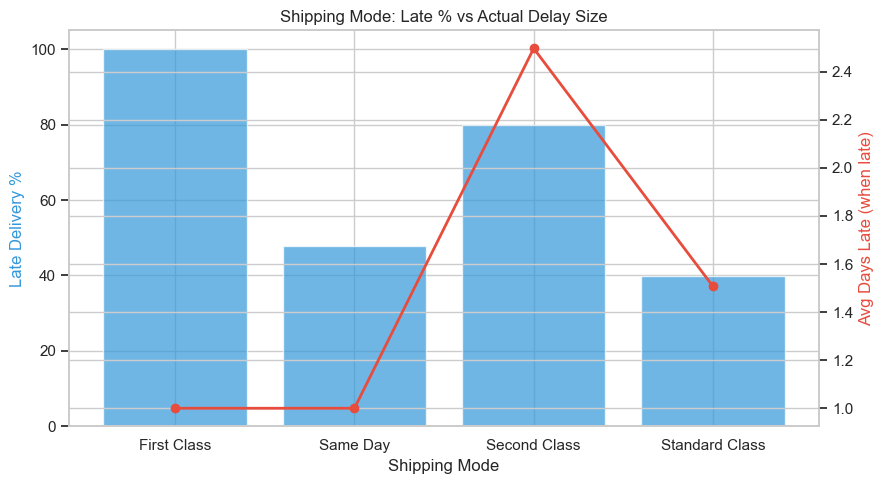

In [24]:
# visualize late % vs actual delay size per shipping mode
fig, ax1 = plt.subplots(figsize=(9, 5))

modes = shipping_mode_analysis.index
ax1.bar(modes, shipping_mode_analysis['late_pct'], color='#3498db', alpha=0.7, label='Late %')
ax1.set_ylabel('Late Delivery %', color='#3498db')
ax1.set_xlabel('Shipping Mode')

ax2 = ax1.twinx()
ax2.plot(modes, shipping_mode_analysis['avg_gap_when_late'], color='#e74c3c', marker='o', linewidth=2, label='Avg Days Late (when late)')
ax2.set_ylabel('Avg Days Late (when late)', color='#e74c3c')

plt.title('Shipping Mode: Late % vs Actual Delay Size')
fig.tight_layout()
plt.show()

In [25]:
# late-delivery % per region
late_by_region = shipped_only[shipped_only['Delivery Status'] == 'Late delivery'].groupby('Order Region').size()
total_by_region = shipped_only.groupby('Order Region').size()

region_late_pct = (late_by_region / total_by_region) * 100
region_late_pct = region_late_pct.sort_values(ascending=False)

print(region_late_pct)

Order Region
Central Africa     60.148515
Western Europe     58.530174
South of  USA      58.521401
South Asia         58.350101
East Africa        58.169568
East of USA        58.168354
Southeast Asia     57.979422
West Asia          57.814132
Eastern Europe     57.648613
US Center          57.526977
South America      57.184151
Central America    57.106057
North Africa       57.096565
Southern Europe    56.799557
West of USA        56.787360
Eastern Asia       56.718772
Central Asia       56.457565
Oceania            56.323847
Northern Europe    56.250000
Southern Africa    56.090909
Caribbean          55.527607
West Africa        54.690563
Canada             51.598677
dtype: float64


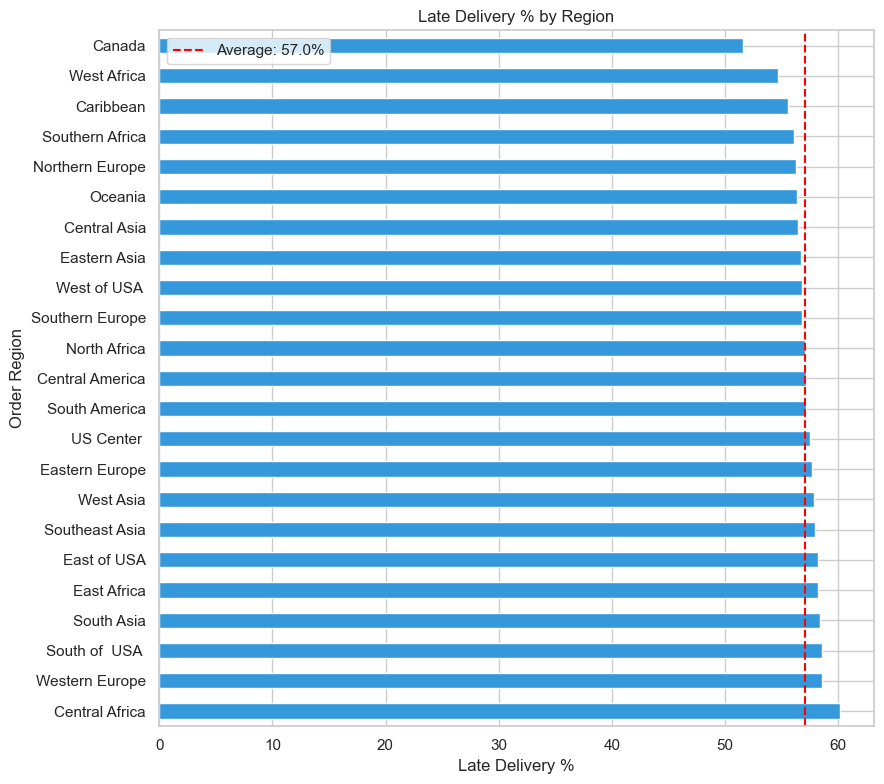

In [26]:
# visualize late delivery % by region
region_late_pct.plot(kind='barh', figsize=(9, 8), color='#3498db')
plt.title('Late Delivery % by Region')
plt.xlabel('Late Delivery %')
plt.axvline(region_late_pct.mean(), color='red', linestyle='--', label=f'Average: {region_late_pct.mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**
Late rates are close everywhere — between 55% and 60% across 21 regions. Canada's the only real outlier, lower at 51.6%. Since it barely changes by region, this doesn't look like a location or logistics issue — more like a scheduling problem that's the same everywhere.

In [27]:
# late-delivery % per customer segment
late_by_segment = shipped_only[shipped_only['Delivery Status'] == 'Late delivery'].groupby('Customer Segment').size()
total_by_segment = shipped_only.groupby('Customer Segment').size()

segment_late_pct = (late_by_segment / total_by_segment) * 100
segment_late_pct = segment_late_pct.sort_values(ascending=False)

print(segment_late_pct)

Customer Segment
Home Office    57.588344
Consumer       57.311563
Corporate      57.078130
dtype: float64


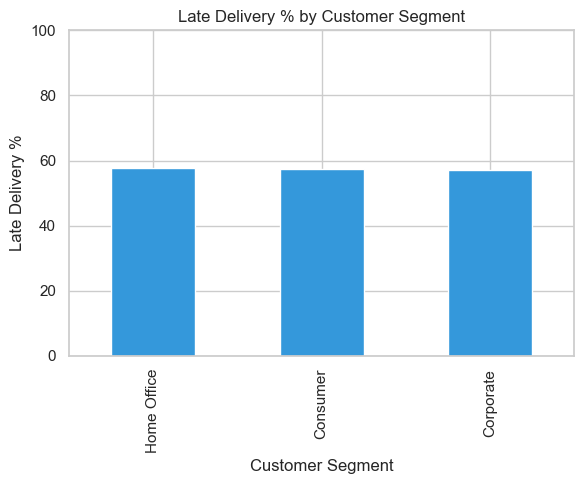

In [28]:
# visualize late delivery % by customer segment
segment_late_pct.plot(kind='bar', figsize=(6, 5), color='#3498db')
plt.title('Late Delivery % by Customer Segment')
plt.ylabel('Late Delivery %')
plt.ylim(0, 100)  # same scale as other late % charts for fair comparison
plt.tight_layout()
plt.show()

**Insight:**
Late rate is basically the same across customer types: Home Office 57.59%, Consumer 57.31%, Corporate 57.08% — less than half a point apart. So customer type isn't the cause either. That's the last variable ruled out (category, discount, quantity, region, segment) — all pointing the same way: this is a systemic scheduling issue, not tied to a specific customer or product.

Before trending, check whether every month has a consistent order volume — trailing months in this dataset (2017-10 through 2018-01) turned out to have roughly half the normal monthly order count, so they're excluded below to avoid building a trend on incomplete data.

In [29]:
# step 1: keep only complete months (exclude 2017-10 through 2018-01)
df_trend = df[df['order date (DateOrders)'] < '2017-10-01'].copy()

# step 2: create the month column
df_trend['order_month'] = df_trend['order date (DateOrders)'].dt.to_period('M')

# step 3: create the True/False loss column
df_trend['is_loss'] = df_trend['Order Profit Per Order'] < 0

# step 4: group by month, average the True/False column = loss percentage
monthly_loss_rate = df_trend.groupby('order_month')['is_loss'].mean() * 100

print(monthly_loss_rate)

order_month
2015-01    19.240887
2015-02    18.439416
2015-03    17.847818
2015-04    19.527897
2015-05    18.349823
2015-06    18.835216
2015-07    18.928100
2015-08    18.149061
2015-09    18.638132
2015-10    18.691060
2015-11    18.414518
2015-12    19.158443
2016-01    18.920444
2016-02    19.942787
2016-03    19.539347
2016-04    18.579557
2016-05    18.785364
2016-06    18.322121
2016-07    18.661640
2016-08    19.610049
2016-09    17.771318
2016-10    17.691738
2016-11    19.193858
2016-12    19.567280
2017-01    18.363044
2017-02    17.081125
2017-03    18.571161
2017-04    18.668457
2017-05    19.522287
2017-06    19.551606
2017-07    19.198947
2017-08    17.568332
2017-09    18.192330
Freq: M, Name: is_loss, dtype: float64


In [30]:
# same approach for the late-delivery side
shipped_trend = shipped_only[shipped_only['order date (DateOrders)'] < '2017-10-01'].copy()
shipped_trend['order_month'] = shipped_trend['order date (DateOrders)'].dt.to_period('M')
shipped_trend['is_late'] = shipped_trend['Delivery Status'] == 'Late delivery'

monthly_late_rate = shipped_trend.groupby('order_month')['is_late'].mean() * 100

print(monthly_late_rate)

order_month
2015-01    56.315995
2015-02    57.811455
2015-03    57.265457
2015-04    56.154629
2015-05    58.010615
2015-06    56.601467
2015-07    57.357533
2015-08    58.427861
2015-09    59.155501
2015-10    57.283659
2015-11    56.604901
2015-12    57.040202
2016-01    57.884427
2016-02    56.587657
2016-03    57.857001
2016-04    57.684426
2016-05    58.505155
2016-06    59.310487
2016-07    55.166199
2016-08    57.032308
2016-09    57.071012
2016-10    56.799846
2016-11    57.413758
2016-12    58.471892
2017-01    55.573217
2017-02    57.368984
2017-03    57.434402
2017-04    56.285141
2017-05    56.464747
2017-06    56.004228
2017-07    57.660333
2017-08    58.579534
2017-09    57.067532
Freq: M, Name: is_late, dtype: float64


**Insight:**
Both numbers — loss rate (~18-19%) and late rate (~57-58%) — stayed flat for all 33 months in the clean data, no real upward or downward trend. If this were something building up over time, like understaffing or a supplier issue, we'd expect it to get gradually worse. It doesn't. That backs up the idea that both problems are just how things run day-to-day, not a one-time event or a slow decline.

# Wrap-up: What This Means & What to Do Next

### 1. The losses aren't one fixable problem — the pricing itself is tight
18.71% of orders (33,784 of 180,519) lose money. I tested category, product, discount rate, quantity, and late delivery status one by one, comparing loss-making vs. profitable orders directly — every single cut came back close to the same loss rate (~18-19%). Even the worst products only reach 21-24%, not far above baseline.

**What to do:** Don't treat this like an operational bug to fix — there's no single lever. It's a pricing/margin question: the catalog is running on thin margins that tip negative on a fairly consistent share of orders, seemingly at random. Worth doing a category-level margin review (not just profit) next, rather than chasing one product or discount rule.

### 2. Late deliveries are actually two different problems
The dataset's reported 54.8% late rate is too low — once cancelled orders (7,754 rows) are removed from the denominator, the real late rate among shipped orders is **57.29%**, and orders that do run late are late by **1.62 days** on average (not 0.57, which was the overall average across everything).

First Class (100% late) and Same Day (47.9% late) look bad mostly because their promised windows (1 day / 0 days) are unrealistic — that's a **promise problem**, not poor execution. Second Class is different: scheduled for 2 days, it runs 2.5 days over on 79.8% of orders — that's a real **execution problem**. Region (55-60% spread across 21 regions) and customer segment (57.08-57.59%) were both checked and ruled out — this isn't a geography or customer-type issue.

**What to do:** Two separate fixes. (1) Look into what's actually slowing down Second Class specifically — that's the mode with a genuine execution gap. (2) Re-set the promised delivery windows for First Class and Same Day, since it's the promise — not the fulfillment — driving their numbers. Any schedule change should be piloted on a subset of orders first, not rolled out everywhere at once.

### 3. The categories with the biggest losses are still the most profitable overall
Fishing, Cleats, and Camping & Hiking show the largest losses in raw dollar terms — but they're also the most profitable categories overall. That's just volume: they sell the most, so they also lose the most in absolute terms, without actually being worse categories.

**What to do:** Keep investing in these three categories, but it'd help to look at profit *margin* per category, not just total profit — that would show whether they're genuinely efficient or just big.